In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df=pd.read_csv("Titanic-Dataset.csv")

In [10]:
df=df[["Age","Fare","SibSp","Survived"]]

In [12]:
df.head()

,Age,Fare,SibSp,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Age       714 non-null    float64
 1   Fare      891 non-null    float64
 2   SibSp     891 non-null    int64  
 3   Survived  891 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 28.0 KB


In [15]:
df.isnull().mean()*100

Age         19.86532
Fare         0.00000
SibSp        0.00000
Survived     0.00000
dtype: float64

In [14]:
sns.histplot()

Age         177
Fare          0
SibSp         0
Survived      0
dtype: int64

In [18]:
X=df.drop(columns=["Survived"],axis=1)
y=df["Survived"]

In [19]:
from sklearn.model_selection import train_test_split

In [20]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=2)

In [22]:
X_train.shape,X_test.shape

((712, 3), (179, 3))

In [25]:
mean_age=df["Age"].mean()
median_age=df["Age"].median()

In [26]:
X_train["mean_age"]=df["Age"].fillna(mean_age)
X_train["median_age"]=df["Age"].fillna(median_age)

In [27]:
X_train.sample(5)

,Age,Fare,SibSp,mean_age,median_age
296,23.5,7.2292,0,23.500000,23.5
521,22.0,7.8958,0,22.000000,22.0
826,NaN,56.4958,0,29.699118,28.0
9,14.0,30.0708,1,14.000000,14.0
184,4.0,22.0250,0,4.000000,4.0


In [33]:
print("Origional age Varience",X_train["Age"].var())
print("Origional median_age Varience",X_train["median_age"].var())
print("Origional mean_age Varience",X_train["mean_age"].var())

Origional age Varience 204.34951339046142
Origional median_age Varience 162.3385298533084
Origional mean_age Varience 161.81386645586778


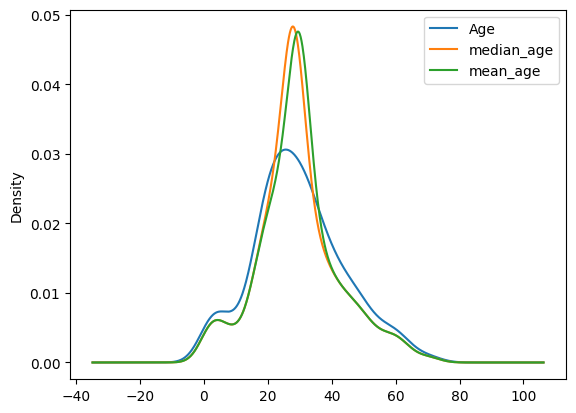

In [38]:
fig=plt.figure()
ax=fig.add_subplot(111)
X_train["Age"].plot(kind="kde",ax=ax)
X_train["median_age"].plot(kind="kde",ax=ax)
X_train["mean_age"].plot(kind="kde",ax=ax)
ax.legend()

In [39]:
X_train.cov()

,Age,Fare,SibSp,mean_age,median_age
Age,204.349513,71.512440,-4.165283,204.349513,204.349513
Fare,71.512440,2368.246832,8.567003,56.824300,60.695143
SibSp,-4.165283,8.567003,1.267996,-3.299378,-3.321504
mean_age,204.349513,56.824300,-3.299378,161.813866,161.838181
median_age,204.349513,60.695143,-3.321504,161.838181,162.338530


In [40]:
X_train.corr()

,Age,Fare,SibSp,mean_age,median_age
Age,1.000000,0.095814,-0.309514,1.000000,1.000000
Fare,0.095814,1.000000,0.156335,0.091794,0.097888
SibSp,-0.309514,0.156335,1.000000,-0.230338,-0.231507
mean_age,1.000000,0.091794,-0.230338,1.000000,0.998533
median_age,1.000000,0.097888,-0.231507,0.998533,1.000000


<Axes: >

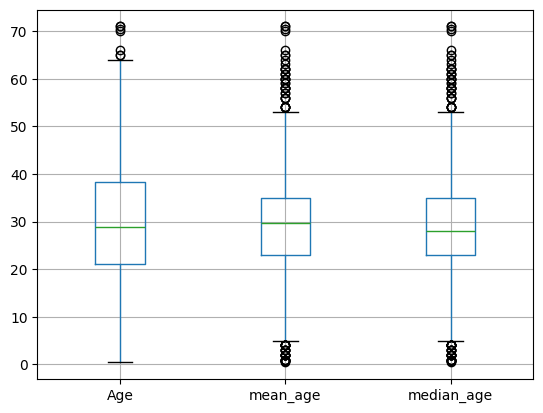

In [41]:
X_train[["Age","mean_age","median_age"]].boxplot()